# Multi-Agent Workflow with LangGraph and Groq

**Updated for VS Code/Jupyter — verified July 22, 2026**

This notebook demonstrates a three-node LangGraph workflow:

1. **Planner agent** — creates a short plan.
2. **Executor agent** — completes each planned step.
3. **Finalizer agent** — combines the work into one answer.

The notebook uses the current `START` and `END` graph API and reads `GROQ_API_KEY` from your environment or a local `.env` file.

## 1. Install the required packages

Run the next cell once in the VS Code notebook kernel. If the packages were newly installed, restart the kernel before continuing.

Pinned versions make the notebook reproducible:

- `langgraph==1.2.9`
- `langchain-groq==1.1.3`

Python 3.10 or newer is required by current LangGraph releases.

In [1]:
!uv add "langgraph==1.2.9" "langchain-groq==1.1.3" "python-dotenv>=1.0.1"

Resolved 71 packages in 0.83ms
Checked 66 packages in 19ms


## 2. Configure the Groq API key

### Option A — `.env` file

Create a `.env` file in the same project folder:

```env
GROQ_API_KEY=gsk_your_key_here
```

Keep `.env` out of Git by adding it to `.gitignore`.

### Option B — GitHub Codespaces secret

If `GROQ_API_KEY` is already configured as a Codespaces secret, it is normally available automatically as an environment variable. No `.env` file is required.

In [2]:
import os
import getpass
from importlib.metadata import version

from dotenv import load_dotenv

load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass(
        "Enter your Groq API key (input will be hidden): "
    )

print("LangGraph version:", version("langgraph"))
print("langchain-groq version:", version("langchain-groq"))

LangGraph version: 1.2.9
langchain-groq version: 1.1.3


## 3. Create the Groq chat model

The old `llama3-8b-8192` model ID has been replaced with a current Groq production model.

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
)

print("Model configured:", llm.model_name)

Model configured: llama-3.3-70b-versatile


## 4. Define the shared LangGraph state

In [4]:
from typing_extensions import TypedDict


class AgentState(TypedDict, total=False):
    user_input: str
    task_list: list[str]
    completed_steps: list[str]
    final_output: str

## 5. Define the agent nodes

In [5]:
import re
from langchain_core.messages import HumanMessage, SystemMessage


def parse_numbered_steps(text: str, maximum: int = 3) -> list[str]:
    """Convert a numbered or bulleted plan into a clean list of steps."""
    steps: list[str] = []

    for raw_line in text.splitlines():
        line = raw_line.strip()
        line = re.sub(r"^\s*(?:[-*•]+|\d+[.)])\s*", "", line).strip()

        if line:
            steps.append(line)

    # Remove duplicates while preserving order.
    unique_steps = list(dict.fromkeys(steps))

    if not unique_steps:
        raise ValueError("The planner returned no usable steps.")

    return unique_steps[:maximum]


def planner_node(state: AgentState) -> dict[str, list[str]]:
    """Create a concise 2-3 step plan for the user's request."""
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a planning agent. Break the user's request into "
                    "2 or 3 concrete, non-overlapping steps. Return only a "
                    "numbered list, with one step per line."
                )
            ),
            HumanMessage(content=state["user_input"]),
        ]
    )

    task_list = parse_numbered_steps(response.content)
    print("Planner output:")
    for index, task in enumerate(task_list, start=1):
        print(f"  {index}. {task}")

    return {"task_list": task_list}


def executor_node(state: AgentState) -> dict[str, list[str]]:
    """Execute each planned step and store the intermediate results."""
    user_input = state["user_input"]
    tasks = state.get("task_list", [])

    if not tasks:
        raise ValueError("No tasks were supplied to the executor.")

    completed_steps: list[str] = []

    for index, task in enumerate(tasks, start=1):
        previous_work = "\n\n".join(completed_steps) or "No previous work yet."

        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are an execution agent. Complete only the assigned "
                        "step accurately and concisely. Use previous work as "
                        "context, but do not repeat it unnecessarily."
                    )
                ),
                HumanMessage(
                    content=(
                        f"Overall user request:\n{user_input}\n\n"
                        f"Assigned step {index}:\n{task}\n\n"
                        f"Previous completed work:\n{previous_work}"
                    )
                ),
            ]
        )

        result = response.content.strip()
        completed_steps.append(f"Step {index} — {task}\n{result}")
        print(f"Completed step {index}.")

    return {"completed_steps": completed_steps}


def finalizer_node(state: AgentState) -> dict[str, str]:
    """Combine all completed work into one user-facing response."""
    completed_work = "\n\n".join(state.get("completed_steps", []))

    if not completed_work:
        raise ValueError("No completed work was supplied to the finalizer.")

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are the final response agent. Combine the completed "
                    "work into one coherent, accurate answer. Answer the user's "
                    "request directly. Do not mention agents, nodes, plans, or "
                    "the internal workflow."
                )
            ),
            HumanMessage(
                content=(
                    f"Original request:\n{state['user_input']}\n\n"
                    f"Completed work:\n{completed_work}"
                )
            ),
        ]
    )

    return {"final_output": response.content.strip()}

## 6. Build and compile the LangGraph workflow

Current LangGraph examples use the `START` and `END` constants to define graph boundaries.

In [6]:
from langgraph.graph import END, START, StateGraph

graph_builder = StateGraph(AgentState)

graph_builder.add_node("planner", planner_node)
graph_builder.add_node("executor", executor_node)
graph_builder.add_node("finalizer", finalizer_node)

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_edge("executor", "finalizer")
graph_builder.add_edge("finalizer", END)

graph = graph_builder.compile()

print("Graph compiled successfully.")

Graph compiled successfully.


## 7. Display the graph

The PNG renderer may require internet access. If rendering fails, the notebook prints the Mermaid source instead.

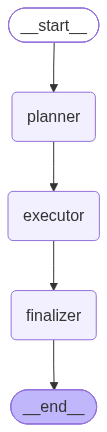

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"PNG rendering was unavailable: {exc}")
    print("\nMermaid diagram source:\n")
    print(graph.get_graph().draw_mermaid())

## 8. Run the workflow

In [8]:
initial_state: AgentState = {
    "user_input": "How do solar panels work?"
}

final_state = graph.invoke(initial_state)

Planner output:
  1. **Photovoltaic Effect**: Solar panels convert sunlight into electrical energy through the photovoltaic effect, where sunlight excites electrons in the panel's semiconductor material, causing them to flow through the material and create an electrical current.
  2. **Energy Collection**: The electrical current generated by the photovoltaic effect is collected by metal contacts on the solar panel and sent through an inverter, which converts the DC power into AC power that can be used by homes and businesses.
  3. **Power Distribution**: The AC power is then distributed to the electrical grid or used directly to power electrical devices, with excess energy often stored in batteries or fed back into the grid for later use.
Completed step 1.
Completed step 2.
Completed step 3.


In [9]:
print(final_state["final_output"])

Solar panels work by converting sunlight into electrical energy through a process known as the photovoltaic effect. This occurs when photons from sunlight hit the semiconductor material in the panel, exciting electrons and causing them to flow, thus generating an electrical current. The electrical current is then collected by metal contacts on the solar panel and sent through an inverter, which converts the DC power into AC power that can be used by homes and businesses. Finally, the AC power is distributed to the electrical grid or used directly to power electrical devices, with excess energy often stored in batteries or fed back into the grid for later use.


## Try another request

Change `initial_state["user_input"]` and run the last two code cells again.